#  Toyota Stock Price Prediction — ARIMA

**Dataset:** `Toyota_Stock_Prices_1980_2026.csv`  
**Task:** Time Series Forecasting — Prediksi harga penutupan (`Close`)  
**Model:** ARIMA (AutoRegressive Integrated Moving Average)

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('Libraries loaded ')

Libraries loaded 


---
## 1.  Cara Melihat Tipe Data

In [2]:
df = pd.read_csv('../Toyota_Stock_Prices_1980_2026.csv')
print('Shape:', df.shape)
print('\nTipe Data:')
df.info()
print('\nSampel Data:')
df.head()

Shape: (11508, 6)

Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11508 non-null  object 
 1   Close   11508 non-null  float64
 2   High    11508 non-null  float64
 3   Low     11508 non-null  float64
 4   Open    11508 non-null  float64
 5   Volume  11508 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 539.6+ KB

Sampel Data:


,Date,Close,High,Low,Open,Volume
0,1980-03-18,1.8207,1.8501,1.8207,1.8207,9343
1,1980-03-19,1.8207,1.8207,1.8207,1.8207,0
2,1980-03-20,1.8207,1.8501,1.8207,1.8207,10277
3,1980-03-21,1.8649,1.8944,1.8649,1.8649,8409
4,1980-03-24,1.8723,1.9017,1.8723,1.8723,2803


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(f'Rentang waktu: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Total data: {len(df)} hari trading')
print('\nStatistik Close price:')
print(df['Close'].describe())

Rentang waktu: 1980-03-18 → 2026-01-30
Total data: 11508 hari trading

Statistik Close price:
count    11508.000000
mean        56.436218
std         51.051420
min          1.783800
25%         15.771775
50%         41.571500
75%         85.989425
max        243.764100
Name: Close, dtype: float64


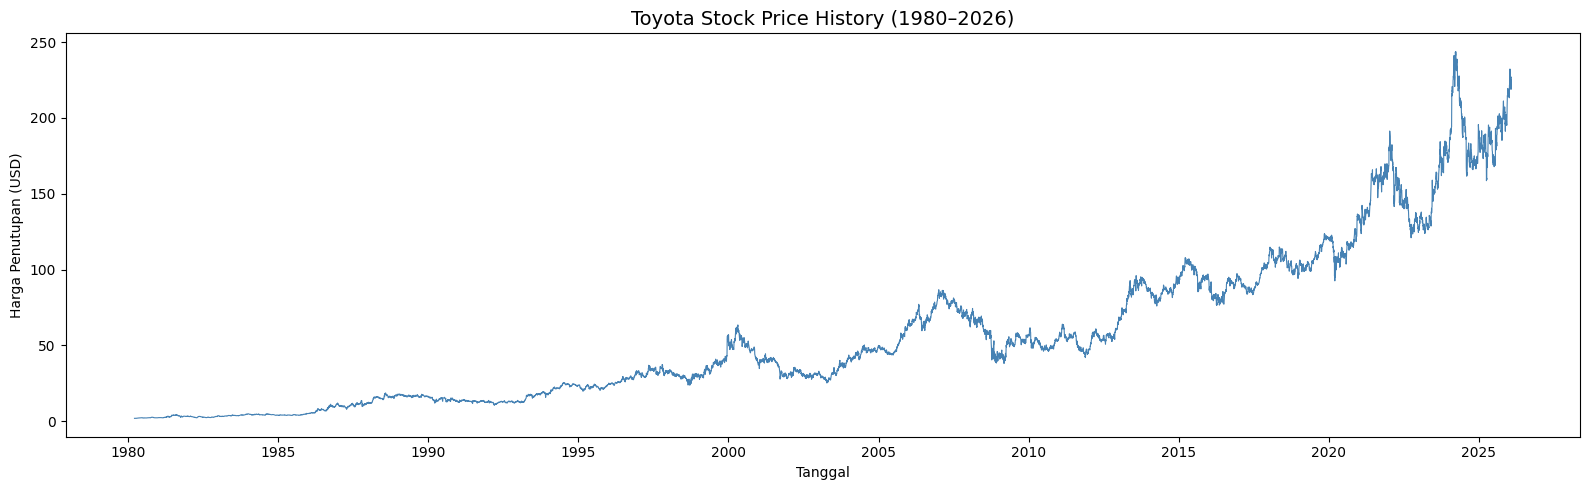

In [4]:
plt.figure(figsize=(16, 5))
plt.plot(df['Date'], df['Close'], linewidth=0.8, color='steelblue')
plt.title('Toyota Stock Price History (1980–2026)', fontsize=14)
plt.xlabel('Tanggal'); plt.ylabel('Harga Penutupan (USD)')
plt.tight_layout()
plt.show()

---
## 2.  Dataset Bisa Digunakan Untuk Apa

| Tujuan | Pendekatan |
|--------|------------|
| **Forecasting Close Price** ← (ini) | Time Series (ARIMA, LSTM, GRU) |
| Prediksi harga besok dari harga hari ini | ML Regression dengan lag features |
| Deteksi anomali harga | Statistik, Isolation Forest |
| Klasifikasi naik/turun | Classification |

###  Pembagian Train/Test untuk Time Series:
- **PENTING:** Jangan pakai random split! Harus secara kronologis.
- Train: 80% data awal, Test: 20% data terakhir

In [5]:
# Gunakan data 5 tahun terakhir untuk lebih relevan
df_recent = df[df['Date'] >= '2015-01-01'].copy()
df_recent = df_recent.set_index('Date')
close_series = df_recent['Close']

# Split kronologis 80/20
n = len(close_series)
split = int(n * 0.8)
train = close_series[:split]
test = close_series[split:]

print(f'Train: {len(train)} obs ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test : {len(test)} obs ({test.index[0].date()} → {test.index[-1].date()})')

Train: 2228 obs (2015-01-02 → 2023-11-07)
Test : 558 obs (2023-11-08 → 2026-01-30)


---
## 3.  Kenapa ARIMA?

**ARIMA(p, d, q)** adalah model statistik klasik untuk time series:

| Komponen | Keterangan |
|----------|------------|
| **AR(p)** | AutoRegressive — nilai masa lalu memprediksi nilai sekarang |
| **I(d)** | Integrated — differencing untuk membuat stasioner |
| **MA(q)** | Moving Average — error masa lalu digunakan sebagai prediktor |

**Cocok ketika:** Data univariat, ingin model yang interpretable, tidak butuh GPU

**Tidak cocok ketika:** Pola non-linear kompleks, butuh banyak fitur eksternal

In [6]:
# Uji Stasioneritas — ADF Test
adf_result = adfuller(train)
print('Augmented Dickey-Fuller Test (ADF)')
print(f'  ADF Statistic : {adf_result[0]:.4f}')
print(f'  p-value       : {adf_result[1]:.6f}')
print(f'  Critical (5%) : {adf_result[4]["5%"]:.4f}')
if adf_result[1] < 0.05:
    print('   Data STASIONER (d=0 mungkin cukup)')
else:
    print('    Data TIDAK STASIONER → perlu differencing (d=1 atau d=2)')

Augmented Dickey-Fuller Test (ADF)
  ADF Statistic : -0.1341
  p-value       : 0.945933
  Critical (5%) : -2.8628
    Data TIDAK STASIONER → perlu differencing (d=1 atau d=2)


Setelah differencing (d=1): p-value = 0.000000
 Stasioner setelah d=1


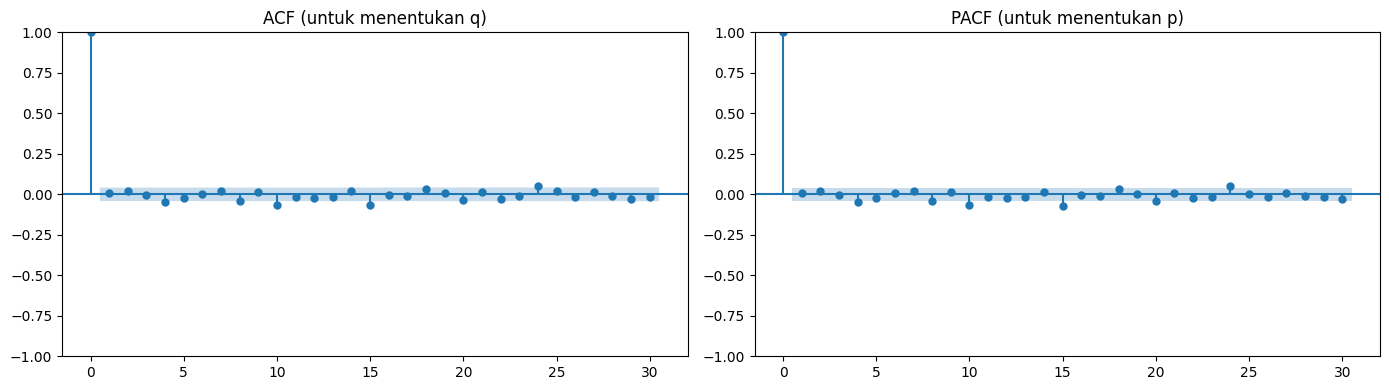

In [7]:
# Differencing untuk membuat stasioner
train_diff = train.diff().dropna()
adf2 = adfuller(train_diff)
print(f'Setelah differencing (d=1): p-value = {adf2[1]:.6f}')
if adf2[1] < 0.05:
    print(' Stasioner setelah d=1')

# Plot ACF PACF untuk menentukan p dan q
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_diff, lags=30, ax=axes[0], title='ACF (untuk menentukan q)')
plot_pacf(train_diff, lags=30, ax=axes[1], title='PACF (untuk menentukan p)')
plt.tight_layout()
plt.show()

---
## 4.  Parameter Yang Bisa Diubah / Disetel

| Parameter | Definisi | Cara Menentukannya |
|-----------|----------|--------------------|
| `p` (AR order) | Jumlah lag autoregressive | PACF — titik signifikan pertama yang cut off |
| `d` (differencing) | Jumlah kali differencing | ADF Test — berapa kali hingga stasioner |
| `q` (MA order) | Jumlah lag moving average | ACF — titik signifikan pertama yang cut off |
| `trend` | Intercept/trend | `'n'`, `'c'`, `'t'`, `'ct'` |

### Tips Memilih Order:
- Coba ARIMA(1,1,1) sebagai baseline
- Pilih kombinasi dengan AIC/BIC terendah

In [8]:
# Cari order terbaik berdasarkan AIC
best_aic = np.inf
best_order = None
results = []

for p in range(0, 3):
    for d in [1]:
        for q in range(0, 3):
            try:
                m = ARIMA(train, order=(p, d, q)).fit()
                results.append({'p': p, 'd': d, 'q': q, 'AIC': m.aic, 'BIC': m.bic})
                if m.aic < best_aic:
                    best_aic = m.aic
                    best_order = (p, d, q)
            except:
                pass

results_df = pd.DataFrame(results).sort_values('AIC').head(5)
print('Top 5 ARIMA orders by AIC:')
print(results_df)
print(f'\n Best ARIMA order: {best_order}')

/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provide

Top 5 ARIMA orders by AIC:
   p  d  q          AIC          BIC
8  2  1  2  8628.954668  8657.496722
0  0  1  0  8641.412837  8647.121248
3  1  1  0  8643.205236  8654.622057
1  0  1  1  8643.213610  8654.630431
2  0  1  2  8644.117786  8661.243018

 Best ARIMA order: (2, 1, 2)


---
## 5.  Evaluasi Yang Dipakai

In [ ]:
# Fit ARIMA dengan best order dan forecast rolling
model = ARIMA(train, order=best_order).fit()

# Rolling forecast — gunakan pd.Series agar freq metadata tetap ada
history = train.copy()
predictions = []
print('Forecasting...', end='')
for i in range(len(test)):
    mod = ARIMA(history, order=best_order).fit()
    yhat = mod.forecast(steps=1).iloc[0]
    predictions.append(yhat)
    # Tambahkan observasi baru ke history
    history = pd.concat([history, test.iloc[i:i+1]])
    if i % 50 == 0: print(f'{i}..', end='')
print(' OK!')

predictions = np.array(predictions)
y_test_arr = test.values

/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Forecasting...0..

/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

50..

/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

...

450..

/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

500..

/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

550.. OK!


In [10]:
mae = mean_absolute_error(y_test_arr, predictions)
rmse = np.sqrt(mean_squared_error(y_test_arr, predictions))
mape = np.mean(np.abs((y_test_arr - predictions) / (y_test_arr + 1e-8))) * 100

# Directional accuracy
actual_dir = np.sign(np.diff(y_test_arr))
pred_dir   = np.sign(np.diff(predictions))
dir_acc = np.mean(actual_dir == pred_dir) * 100

print('=' * 50)
print(' EVALUASI ARIMA')
print('=' * 50)
print(f'MAE             : {mae:.4f}')
print(f'RMSE            : {rmse:.4f}')
print(f'MAPE            : {mape:.2f}%')
print(f'Directional Acc : {dir_acc:.2f}%')

 EVALUASI ARIMA
MAE             : 2.4914
RMSE            : 3.4192
MAPE            : 1.30%
Directional Acc : 49.55%


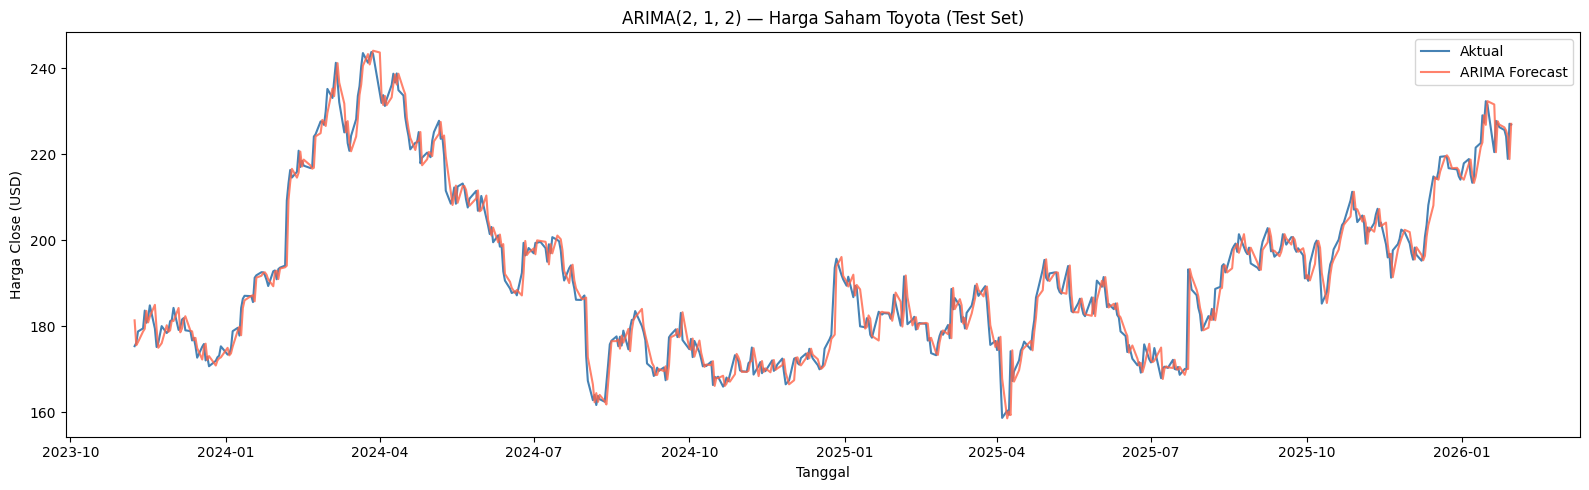

In [11]:
plt.figure(figsize=(16, 5))
plt.plot(test.index, y_test_arr, label='Aktual', color='steelblue')
plt.plot(test.index, predictions, label='ARIMA Forecast', color='tomato', alpha=0.8)
plt.title(f'ARIMA{best_order} — Harga Saham Toyota (Test Set)')
plt.xlabel('Tanggal'); plt.ylabel('Harga Close (USD)')
plt.legend(); plt.tight_layout()
plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

### Benchmark untuk stock price forecasting:

| Metrik | Sangat Baik | Cukup | Perlu Review |
|--------|------------|-------|----------|
| MAPE | < 2% | 2–5% | > 5% |
| Directional Acc | > 55% | 50–55% | < 50% (lebih buruk dari random) |

### Residual Analysis:
- Residual harus seperti white noise (tidak ada pola)
- Ljung-Box test: p-value > 0.05 → residual independen

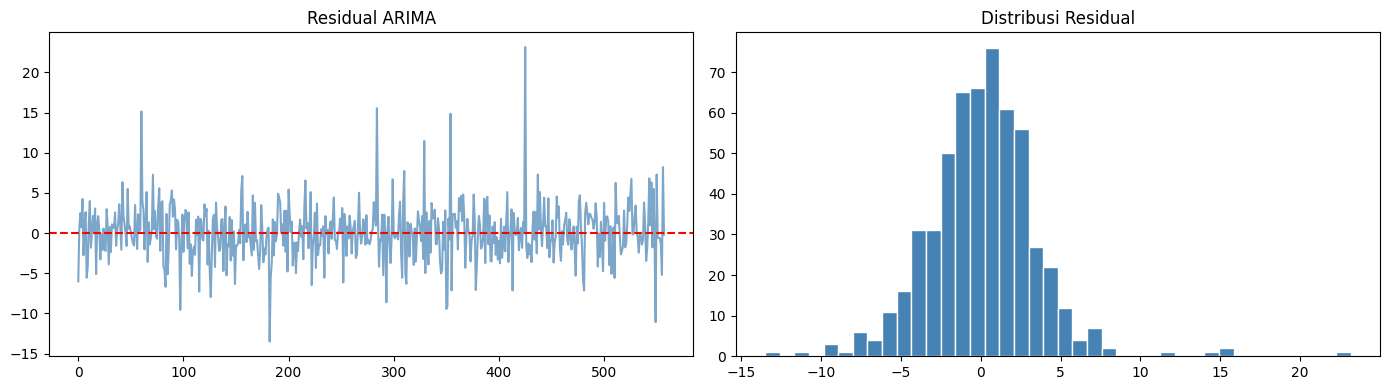

Mean residual: 0.0908 (idealnya ≈ 0)


In [12]:
residuals = y_test_arr - predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(residuals, alpha=0.7, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residual ARIMA')
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Distribusi Residual')
plt.tight_layout(); plt.show()
print(f'Mean residual: {np.mean(residuals):.4f} (idealnya ≈ 0)')

---
## 7.  Cara Mengoptimasi Model

### Untuk ARIMA:
1. **Coba auto_arima** dari library `pmdarima` (seperti GridSearch otomatis)
2. **SARIMA** jika ada pola musiman (S=12 untuk bulanan, S=252 untuk tahunan)
3. **ARIMAX** jika ada fitur tambahan (volume, indeks pasar)
4. **GARCH** untuk memodelkan volatilitas

```python
# Auto ARIMA — otomatis cari p, d, q terbaik
# !pip install pmdarima
from pmdarima import auto_arima
auto_model = auto_arima(train, seasonal=False, stepwise=True, information_criterion='aic')
print(auto_model.order)
```

---
## 8.  Cara Menyimpan Model

In [13]:
os.makedirs('saved_models', exist_ok=True)

# Fit ARIMA final pada seluruh data
final_model = ARIMA(close_series, order=best_order).fit()
final_model.save('saved_models/arima_toyota.pkl')
joblib.dump(best_order, 'saved_models/arima_order.pkl')

print(f'Model ARIMA{best_order} tersimpan ')

/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Model ARIMA(2, 1, 2) tersimpan 


---
## 9.  Cara Menggunakan Model Hasil Training

Model ARIMA(2, 1, 2) dimuat 


/home/arilix/Documents/module-kaggle/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


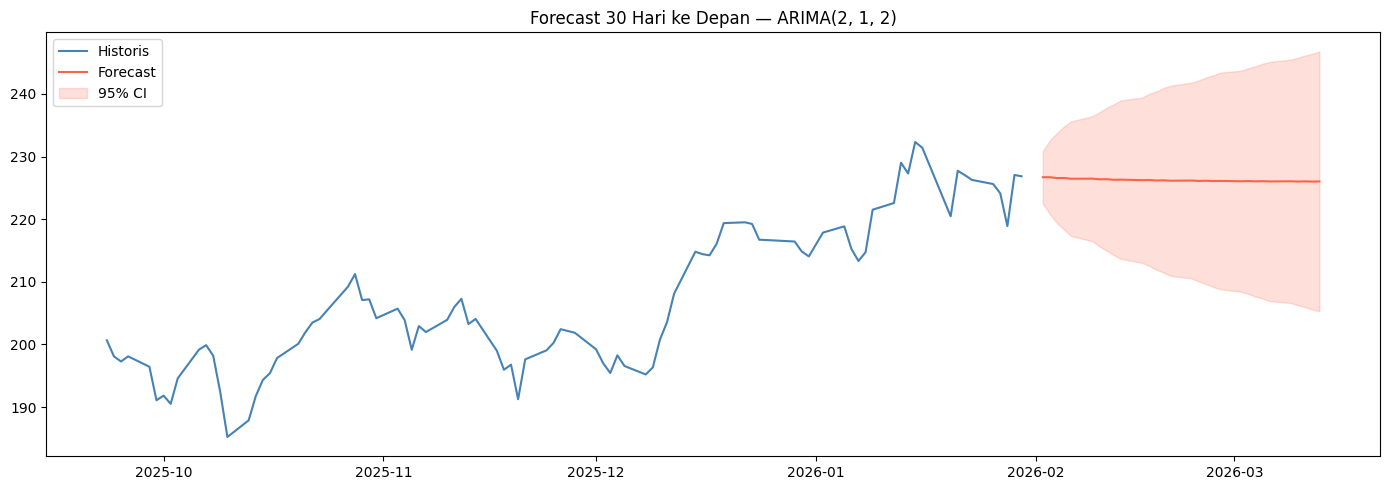


Prediksi harga besok: $226.71


In [14]:
from statsmodels.tsa.arima.model import ARIMAResults

loaded_model = ARIMAResults.load('saved_models/arima_toyota.pkl')
loaded_order = joblib.load('saved_models/arima_order.pkl')
print(f'Model ARIMA{loaded_order} dimuat ')

# Forecast 30 hari ke depan
n_forecast = 30
forecast_result = loaded_model.get_forecast(steps=n_forecast)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

plt.figure(figsize=(14, 5))
last_part = close_series.iloc[-90:]
plt.plot(last_part.index, last_part.values, label='Historis', color='steelblue')
future_dates = pd.date_range(start=close_series.index[-1] + pd.Timedelta(days=1), periods=n_forecast, freq='B')
plt.plot(future_dates, forecast_mean.values, label='Forecast', color='tomato')
plt.fill_between(future_dates, conf_int.iloc[:, 0].values, conf_int.iloc[:, 1].values, alpha=0.2, color='tomato', label='95% CI')
plt.title(f'Forecast 30 Hari ke Depan — ARIMA{loaded_order}')
plt.legend(); plt.tight_layout()
plt.show()

print(f'\nPrediksi harga besok: ${forecast_mean.values[0]:.2f}')